# AirBnB
https://insideairbnb.com/get-the-data/

In [240]:
import pandas as pd

In [241]:
df = pd.read_csv('listings.csv')

In [242]:
df.head(3)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,821198084644106078,https://www.airbnb.com/rooms/821198084644106078,20250926170004,2025-09-27,city scrape,Bright and Peaceful Leblon Loft,Welcome! Come relax in our bright and stylish ...,Beautiful tree lined street just 3 blocks from...,https://a0.muscache.com/pictures/hosting/Hosti...,84350716,...,4.94,4.99,4.85,NaN,f,1,1,0,0,2.72
1,821198370698658112,https://www.airbnb.com/rooms/821198370698658112,20250926170004,2025-09-27,city scrape,Copacabana 100% reformado.,Guarantee of a safe and quality stay! <br /><...,"Copacabana, in the part near the neighborhood ...",https://a0.muscache.com/pictures/miso/Hosting-...,4347269,...,NaN,NaN,NaN,NaN,f,2,2,0,0,NaN
2,821200521820144734,https://www.airbnb.com/rooms/821200521820144734,20250926170004,2025-09-26,city scrape,hambiente familia,Relax with the whole family in this quiet acco...,NaN,https://a0.muscache.com/pictures/7485ea61-a28a...,499903412,...,NaN,NaN,NaN,NaN,t,2,1,1,0,NaN


In [243]:
df.room_type

0        Entire home/apt
1        Entire home/apt
2        Entire home/apt
3           Private room
4        Entire home/apt
              ...       
43063    Entire home/apt
43064       Private room
43065    Entire home/apt
43066       Private room
43067       Private room
Name: room_type, Length: 43068, dtype: str

In [244]:
col_interes = ['id', 'name', 'host_name', 'host_location', 'host_response_time', 'host_is_superhost', 'neighbourhood', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights', 'number_of_reviews', 'number_of_reviews_l30d', 'review_scores_rating', 'instant_bookable']

room_trad = {'Entire home/apt': 'Todo o espaço',
             'Private room': 'Quarto privativo',
             'Shared room' : 'Quarto compartilhado'}

In [245]:
df_treatment = df[col_interes].copy()

In [246]:
df_treatment.head(3)

,id,name,host_name,host_location,host_response_time,host_is_superhost,neighbourhood,neighbourhood_cleansed,latitude,longitude,...,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,number_of_reviews_l30d,review_scores_rating,instant_bookable
0,821198084644106078,Bright and Peaceful Leblon Loft,Katrina,"Minnesota, United States",within an hour,f,"Rio de Janeiro, Brazil",Leblon,-22.982818,-43.222457,...,4,1.5,2.0,3.0,$580.00,2,86,2,4.93,f
1,821198370698658112,Copacabana 100% reformado.,Patrick,"Rio de Janeiro, Brazil",within an hour,f,"Rio de Janeiro, Brazil",Copacabana,-22.984090,-43.191770,...,2,2.0,1.0,1.0,"$1,900.00",5,0,0,NaN,f
2,821200521820144734,hambiente familia,Vanessa,NaN,NaN,f,NaN,Pavuna,-22.814911,-43.379011,...,4,1.0,1.0,1.0,$700.00,1,0,0,NaN,t


In [247]:
df_treatment['room_type'] = df_treatment['room_type'].map(room_trad)

In [248]:
df_treatment.info()

<class 'pandas.DataFrame'>
RangeIndex: 43068 entries, 0 to 43067
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      43068 non-null  int64  
 1   name                    43068 non-null  str    
 2   host_name               43057 non-null  str    
 3   host_location           34195 non-null  str    
 4   host_response_time      35890 non-null  str    
 5   host_is_superhost       41613 non-null  str    
 6   neighbourhood           16330 non-null  str    
 7   neighbourhood_cleansed  43068 non-null  str    
 8   latitude                43068 non-null  float64
 9   longitude               43068 non-null  float64
 10  property_type           43068 non-null  str    
 11  room_type               43046 non-null  str    
 12  accommodates            43068 non-null  int64  
 13  bathrooms               38635 non-null  float64
 14  bedrooms                42096 non-null  float64
 

In [249]:
df.host_response_time.value_counts()

host_response_time
within an hour        22227
within a few hours     6131
within a day           4258
a few days or more     3274
Name: count, dtype: int64

In [250]:
df_treatment['price_cleaned'] = df_treatment['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

In [251]:
remap_boolean = {'t' :  True, 'f': False}
df_treatment['host_is_superhost'] = df_treatment['host_is_superhost'].replace(remap_boolean).astype(bool)
df_treatment['instant_bookable'] = df_treatment['instant_bookable'].replace(remap_boolean).astype(bool)

In [252]:
def get_marker_color(room_type):
    cores = {
        'Entire home/apt': 'red',
        'Private room': 'blue',
        'Shared room': 'green'
    }
    return cores.get(room_type, 'gray')

In [253]:
df_treatment.price_cleaned.describe()

count     38670.000000
mean        717.535325
std        4388.082802
min          30.000000
25%         202.000000
50%         317.000000
75%         565.000000
max      500000.000000
Name: price_cleaned, dtype: float64

In [254]:
pd.set_option('display.max_rows', 10)

In [255]:
Bairros_perigosos = ['Centro', 'Bonsucesso', 'São Cristóvão', 'Caju', 'Pavuna', 'Complexo do Alemão', 'Complexo da Maré', 'Irajá', 'Piedade', 'Cascadura', 'Costas Barros', 'Senador Camará', 'Parada de Lucas', 'Brás de Pina', 'Vigário Geral', 'Barros Filhos', 'Complexo do Alemão', 'Triagem', 'Vila Kosmos']

In [256]:
df_treatment['bairro_perigoso'] = df_treatment['neighbourhood_cleansed'].isin(Bairros_perigosos).astype(int)

# 3. Verifique o resultado
print(df_treatment[['neighbourhood_cleansed', 'bairro_perigoso']].head(100))

      neighbourhood_cleansed  bairro_perigoso
0                     Leblon                0
1                 Copacabana                0
2                     Pavuna                1
3                     Leblon                0
4            Barra da Tijuca                0
..                       ...              ...
95               Jacarepaguá                0
96           Jardim Botânico                0
97  Recreio dos Bandeirantes                0
98                  Flamengo                0
99                  Botafogo                0

[100 rows x 2 columns]


In [257]:
df_treatment.to_csv("AirBnBLimpo.csv")

In [258]:
import matplotlib.pyplot as plt
import seaborn as sns 

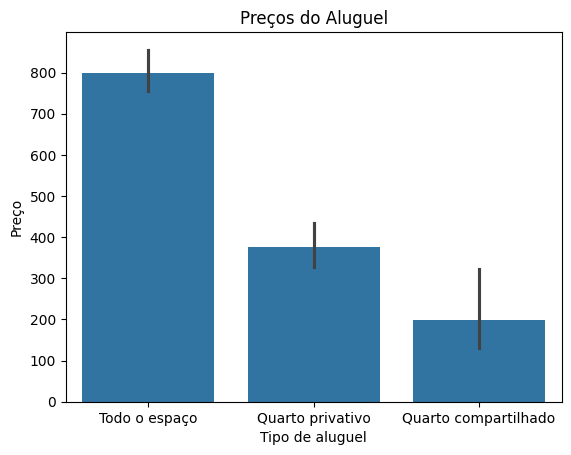

In [259]:
sns.barplot(df_treatment,
            x='room_type',
            y='price_cleaned')


plt.title('Preços do Aluguel')
plt.xlabel('Tipo de aluguel')
plt.ylabel('Preço')
plt.show()

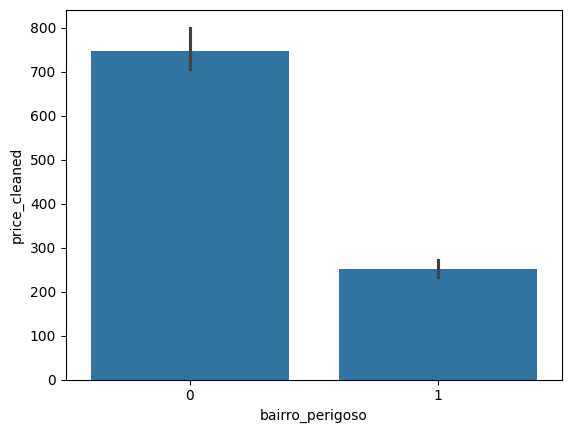

In [260]:
sns.barplot(df_treatment,
            x='bairro_perigoso',
            y='price_cleaned')

plt.show()

- total host
- avg price
- avg number review
- total listing
- gráfico de total de alugueis por bairro e tipo de aluguel
- grafico de numero de reviews
- mapa dos locais
- seleção de rating


- treinar para obter rating?
- treinar para prever preço?

In [261]:
df_treatment.minimum_nights.describe()

count    43068.000000
mean         3.652155
std         15.394401
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max       1000.000000
Name: minimum_nights, dtype: float64

In [262]:
# df_treatment.bedrooms = df_treatment.bedrooms.fillna(df_treatment.bedrooms.median())
# df_treatment.beds = df_treatment.beds.fillna(df_treatment.beds.median())
# df_treatment.bathrooms = df_treatment.bathrooms.fillna(df_treatment.bathrooms.median())
# df_treatment.review_scores_rating = df_treatment.review_scores_rating.fillna(0)
df_treatment.host_response_time = df_treatment.host_response_time.fillna("Não informado")

In [263]:
df_treatment.info()

<class 'pandas.DataFrame'>
RangeIndex: 43068 entries, 0 to 43067
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      43068 non-null  int64  
 1   name                    43068 non-null  str    
 2   host_name               43057 non-null  str    
 3   host_location           34195 non-null  str    
 4   host_response_time      43068 non-null  str    
 5   host_is_superhost       43068 non-null  bool   
 6   neighbourhood           16330 non-null  str    
 7   neighbourhood_cleansed  43068 non-null  str    
 8   latitude                43068 non-null  float64
 9   longitude               43068 non-null  float64
 10  property_type           43068 non-null  str    
 11  room_type               43046 non-null  str    
 12  accommodates            43068 non-null  int64  
 13  bathrooms               38635 non-null  float64
 14  bedrooms                42096 non-null  float64
 

In [264]:
df_rating_pred = df_treatment.copy()
df_rating_pred = df_rating_pred.dropna(subset=['room_type'])

In [265]:
df_treatment.room_type.value_counts()

room_type
Todo o espaço           34495
Quarto privativo         8124
Quarto compartilhado      427
Name: count, dtype: int64

## Previsão de Rating

In [266]:
from sklearn.linear_model import SGDRegressor, Lasso
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import preprocessing
import numpy as np
RANDOM_SEED = 42

df_rating_pred = df_rating_pred.dropna()
df_copa = df_rating_pred[df_rating_pred['neighbourhood_cleansed'] == 'Copacabana']
X = df_rating_pred.drop(columns=['review_scores_rating'])
y = df_rating_pred['review_scores_rating'].values
# X = df_copa.drop(columns=['review_scores_rating'])
# y = df_copa['review_scores_rating'].values

In [267]:
X.room_type.value_counts()

room_type
Todo o espaço           10108
Quarto privativo         1733
Quarto compartilhado       79
Name: count, dtype: int64

In [268]:
enc = preprocessing.OneHotEncoder()
enc.fit(df_rating_pred[['room_type']])
# enc.categories_
one_hot = enc.transform(df_rating_pred[['room_type']]).toarray()
# one_hot = enc.transform(df_copa[['room_type']]).toarray()
X[['Quarto compartilhado', 'Quarto privativo', 'Todo o espaço']] = one_hot
cat_cols = ['host_is_superhost', 'bairro_perigoso', 'instant_bookable', 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado']
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'price_cleaned']

Text(0.5, 1.0, 'Correlation Heatmap')

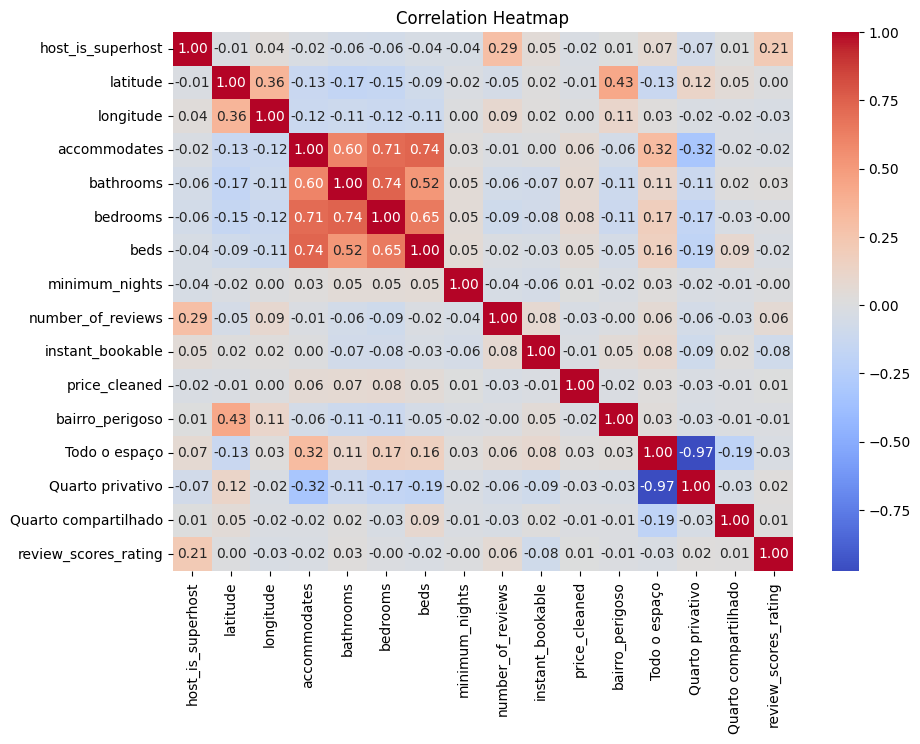

In [269]:
plt.figure(figsize=(10, 7))
X_com_y = X[[
    'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'instant_bookable', 'price_cleaned', 'bairro_perigoso', 
    'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'
    ]].copy()

X_com_y['review_scores_rating'] = y

corr = X_com_y.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')

In [270]:
enc.categories_

[array(['Quarto compartilhado', 'Quarto privativo', 'Todo o espaço'],
       dtype=object)]

In [271]:
precomputador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols)
    ])

In [272]:
pipeline_lasso = Pipeline(steps=[
    ('pre-processamento', precomputador),
    ('modelo', Lasso(alpha=0.0001))
])

In [273]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

scaler = StandardScaler() #usando RobustScaler para lidar melhor com outliers
scaler.fit(X_train[num_cols]) #ajustando o scaler apenas nos dados de treino

X_train[num_cols] = scaler.transform(X_train[num_cols]) #transformando os dados de treino
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [274]:
categorical_data = X_train[cat_cols].values
inputs = np.concatenate((X_train[num_cols], categorical_data), axis=1)
targets= y

In [275]:
pipeline_lasso.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre-processamento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [276]:
test = np.concatenate((X_test[num_cols], X_test[cat_cols].values), axis=1)
y_pred = pipeline_lasso.predict(X_test)

In [277]:
import plotly.express as px
df_resultados = pd.DataFrame({
    'id_imovel': X_test['id'],       # Busca o ID original que ficou de fora do treino
    'nota_real': y_test,             # A nota real (Target)
    'nota_prevista': y_pred      # A nota que a árvore calculou
})
df_resultados.reset_index(drop=True, inplace=True)


fig = px.line(df_resultados, y=['nota_real', 'nota_prevista'])
fig.show()
print(df_resultados.head())

            id_imovel  nota_real  nota_prevista
0            54387768       4.83       4.776237
1  772471073482961996       4.88       4.854584
2            41144885       4.82       4.910057
3              557344       5.00       4.784354
4            22927640       4.74       4.784723


In [278]:
from sklearn.metrics import mean_squared_error, r2_score

In [279]:
mse = mean_squared_error(y_test, y_pred)
mse

0.05354044380065061

In [280]:
r2_score(y_test, y_pred)

0.06571045882615079

In [281]:
pipeline_lasso

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre-processamento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

## Previsão de preços

In [282]:
df_price_pred = df_rating_pred.copy()
df_copa = df_price_pred[df_price_pred['neighbourhood_cleansed'] == 'Leblon']
df_copa = df_price_pred[df_price_pred['room_type'] == 'Quarto privativo']

In [283]:
df_copa.info()

<class 'pandas.DataFrame'>
Index: 1733 entries, 8 to 42096
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      1733 non-null   int64  
 1   name                    1733 non-null   str    
 2   host_name               1733 non-null   str    
 3   host_location           1733 non-null   str    
 4   host_response_time      1733 non-null   str    
 5   host_is_superhost       1733 non-null   bool   
 6   neighbourhood           1733 non-null   str    
 7   neighbourhood_cleansed  1733 non-null   str    
 8   latitude                1733 non-null   float64
 9   longitude               1733 non-null   float64
 10  property_type           1733 non-null   str    
 11  room_type               1733 non-null   str    
 12  accommodates            1733 non-null   int64  
 13  bathrooms               1733 non-null   float64
 14  bedrooms                1733 non-null   float64
 15  be

In [284]:
X = df_copa.drop(columns=['price_cleaned'])
y = df_copa['price_cleaned'].values

In [285]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso

# ==============================================================================
# 1. CONFIGURAÇÃO DAS COLUNAS E SPLIT
# ==============================================================================
# Nota: Garanta que 'review_scores_rating' NÃO esteja em num_cols se ele for o seu 'y'
# (Vou assumir que você o removeu de num_cols se ele for o target)

cat_cols = ['host_is_superhost', 'bairro_perigoso', 'instant_bookable']
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews'] 

# Garanta que o X tenha as colunas originais do OneHot que você criou antes
X_focado = X[['id'] + cat_cols + num_cols] 

X_train, X_test, y_train, y_test = train_test_split(X_focado, y, test_size=0.2, random_state=RANDOM_SEED)

# ==============================================================================
# 2. CONSTRUÇÃO DO PIPELINE POLINOMIAL (O jeito correto)
# ==============================================================================

# O precomputador apenas limpa e padroniza os dados iniciais
precomputador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols), # Você mencionou RobustScaler no comentário, se quiser trocar: RobustScaler()
        ('cat', OneHotEncoder(sparse_output=False), cat_cols)
    ],
    remainder='drop' # Garante que ID e Faixa de Preço fiquem de fora do treino
)

# Montamos o Pipeline de forma sequencial
pipeline_lasso = Pipeline(steps=[
    ('pre-processamento', precomputador),
    
    # PASSO POLINOMIAL: Ele vai receber os dados limpos do precomputador 
    # e criar as interações de grau 4 automaticamente antes de mandar para o Lasso
    ('polinomial', PolynomialFeatures(degree=3, include_bias=False)),
    
    ('modelo', Lasso(alpha=0.0001, max_iter=5000)) # max_iter maior ajuda o Lasso a convergir com muitas colunas
])

# ==============================================================================
# 3. TREINAMENTO E PREVISÃO
# ==============================================================================

# O pipeline faz tudo sozinho! Escalona, cria os polinômios e treina o Lasso.
pipeline_lasso.fit(X_train, y_train)

# Na hora de prever, ele faz as mesmas transformações nos dados de teste automaticamente
y_pred = pipeline_lasso.predict(X_test)

/home/felipe/Estudos/VirtualEnv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.421e+08, tolerance: 3.307e+04
  model = cd_fast.enet_coordinate_descent(


In [305]:
from sklearn.compose import TransformedTargetRegressor
import numpy as np

def travar_minimo(y):
    return np.clip(y, a_min=0, a_max=None)

def identidade(y):
    return y

# 2. Crie o seu pipeline original até o passo polinomial (sem o Lasso no final)
pipeline_recursos = Pipeline(steps=[
    ('pre-processamento', precomputador),
    ('polinomial', PolynomialFeatures(degree=1, include_bias=False))
])

# 3. Encapsule o Lasso dentro do TransformedTargetRegressor
modelo_com_trava = TransformedTargetRegressor(
    regressor=Lasso(alpha=0.0001, max_iter=5000),
    func=identidade,          # Como os dados entram no treino
    inverse_func=travar_minimo # Como as previsões saem no predict (forçando >= 0)
)

# 4. Monte o Pipeline Final
pipeline_lasso_blindado = Pipeline(steps=[
    ('features', pipeline_recursos),
    ('modelo_trava', modelo_com_trava)
])

# 5. Treine e preveja normalmente
pipeline_lasso_blindado.fit(X_train, y_train)

# Aqui, y_pred NUNCA terá valores menores que 0
y_pred = pipeline_lasso_blindado.predict(X_test)

In [306]:
df_resultados_arvore = pd.DataFrame({
    'id_imovel': X_test['id'],       # Busca o ID original que ficou de fora do treino
    'preço_real': y_test,             # A nota real (Target)
    'preço_previsto': y_pred      # A nota que a árvore calculou
})
df_resultados_arvore.reset_index(drop=True, inplace=True)
df_resultados_arvore['erro'] = (df_resultados_arvore['preço_real'] - df_resultados_arvore['preço_previsto']).abs() / df_resultados_arvore['preço_real'] 


fig = px.line(df_resultados_arvore, y=['preço_real', 'preço_previsto'])
fig.update_yaxes(range=[0, 1000])
fig.show()
df_final_polinomial = df_resultados_arvore[df_resultados_arvore['erro'] <=0.6].copy()
print(df_resultados_arvore[df_resultados_arvore['erro'] >=0.1].head())
mse = mean_squared_error(df_final_polinomial['preço_real'], df_final_polinomial['preço_previsto'])
print(mse)
print(r2_score(df_final_polinomial['preço_real'], df_final_polinomial['preço_previsto']))
print(r2_score(y_test, y_pred))

             id_imovel  preço_real  preço_previsto      erro
0  1139086252167755720       304.0      352.599734  0.159868
1             14917170       540.0      236.657815  0.561745
2             40942622       168.0      266.899359  0.588687
3   981053303443856038       306.0      245.842004  0.196595
4  1257359083270330499       516.0      321.419069  0.377095
19344.475671996173
0.28992275074692675
0.05467857609058513


In [288]:
enc = preprocessing.OneHotEncoder()
enc.fit(df_rating_pred[['room_type']])
# enc.categories_
one_hot = enc.transform(df_copa[['room_type']]).toarray()
X[['Quarto compartilhado', 'Quarto privativo', 'Todo o espaço']] = one_hot
cat_cols = ['host_is_superhost', 'bairro_perigoso', 'instant_bookable']#, 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado']
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']

Text(0.5, 1.0, 'Correlation Heatmap')

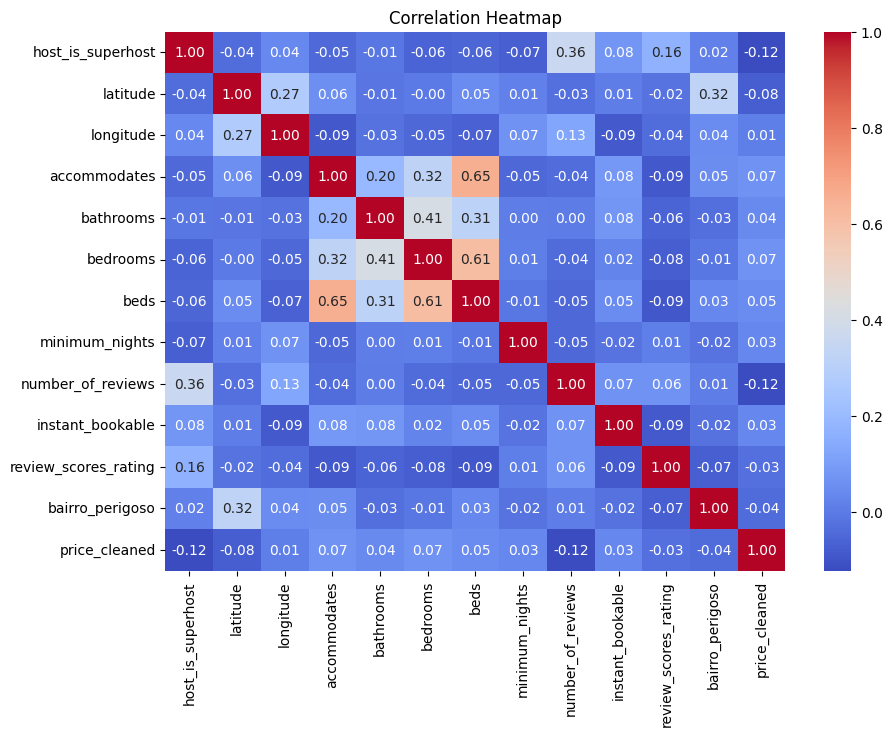

In [289]:
plt.figure(figsize=(10, 7))
X_com_y = X[[
    'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'instant_bookable', 'review_scores_rating', 'bairro_perigoso'#, 
    #'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'
    ]].copy()

X_com_y['price_cleaned'] = y

corr = X_com_y.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')

In [292]:
precomputador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols)
    ])

In [293]:
pipeline_lasso = Pipeline(steps=[
    ('pre-processamento', precomputador),
    ('modelo', Lasso(alpha=0.0001))
])

In [294]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

scaler = StandardScaler() #usando RobustScaler para lidar melhor com outliers
scaler.fit(X_train[num_cols]) #ajustando o scaler apenas nos dados de treino

X_train[num_cols] = scaler.transform(X_train[num_cols]) #transformando os dados de treino
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [295]:
categorical_data = X_train[cat_cols].values
inputs = np.concatenate((X_train[num_cols], categorical_data), axis=1)
targets= y

In [296]:
pipeline_lasso.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre-processamento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [297]:
test = np.concatenate((X_test[num_cols], X_test[cat_cols].values), axis=1)
y_pred = pipeline_lasso.predict(X_test)

In [298]:
df_lasso = pd.DataFrame({'Real Values': y_test, 'Predicted_Values': y_pred})

import plotly.express as px

fig = px.line(df_lasso, y=['Real Values', 'Predicted_Values'])
fig.show()

In [299]:
mse = mean_squared_error(y_test, y_pred)
print(mse)
print(r2_score(y_test, y_pred))

51119.20949638648
0.053633505710439455


In [302]:
def estimate_charges(number_of_reviews, w, b):
    return w*number_of_reviews + b

def try_parameters(w,b):
    number_of_reviews = df_rating_pred.bathrooms
    target = df_rating_pred.price_cleaned

    estimated_charges = estimate_charges(number_of_reviews, w, b)

    plt.plot(number_of_reviews, estimated_charges, 'r', alpha=0.9);
    plt.scatter(number_of_reviews,target, s=8, alpha=0.8);
    plt.ylabel('Preço');
    # plt.xscale('log')
    plt.xlabel('Quantidade de reviews')
    # plt.ylim((0,20000))
    # plt.xlim((20,750))
    plt.legend(['Estimativa', 'Atual']);


In [303]:
X_train.columns

Index(['id', 'name', 'host_name', 'host_location', 'host_response_time',
       'host_is_superhost', 'neighbourhood', 'neighbourhood_cleansed',
       'latitude', 'longitude', 'property_type', 'room_type', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights',
       'number_of_reviews', 'number_of_reviews_l30d', 'review_scores_rating',
       'instant_bookable', 'bairro_perigoso', 'Quarto compartilhado',
       'Quarto privativo', 'Todo o espaço'],
      dtype='str')

dict_keys(['num__accommodates', 'num__bathrooms', 'num__bedrooms', 'num__beds', 'num__number_of_reviews', 'num__review_scores_rating', 'cat__host_is_superhost_False', 'cat__host_is_superhost_True', 'cat__bairro_perigoso_0', 'cat__bairro_perigoso_1', 'cat__instant_bookable_False', 'cat__instant_bookable_True'])


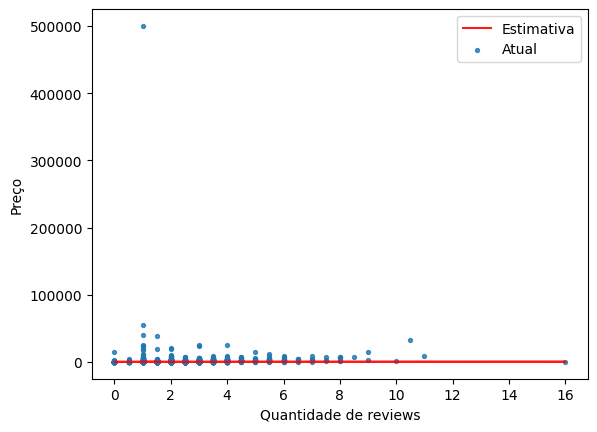

In [307]:
# 1. Garanta que o pipeline já foi treinado (ex: pipeline_lasso.fit(X_train, y_train))

# 2. Extrai os nomes reais das colunas após o pré-processamento
# Acessamos o 'pre-processamento' dentro do pipeline
nomes_colunas_transformadas = pipeline_lasso.named_steps['pre-processamento'].get_feature_names_out()

# 3. Faz o zip correto com os coeficientes do Lasso
coef_dict = dict(zip(nomes_colunas_transformadas, pipeline_lasso.named_steps['modelo'].coef_))

# 4. Para buscar a feature numérica 'number_of_reviews'
# Como ela passou pelo StandardScaler, o nome dela geralmente continua igual, 
# precedido pelo prefixo do transformer (ex: 'num__number_of_reviews')
# Vamos imprimir o dicionário para você ver exatamente como ficou o nome:
print(coef_dict.keys()) 

# Buscando o coeficiente correto (ajuste o nome se o get_feature_names_out colocou prefixo)
price_coef = coef_dict.get('num__bathrooms', coef_dict.get('bathrooms'))

# 5. Executa sua função
try_parameters(price_coef, pipeline_lasso.named_steps['modelo'].intercept_)

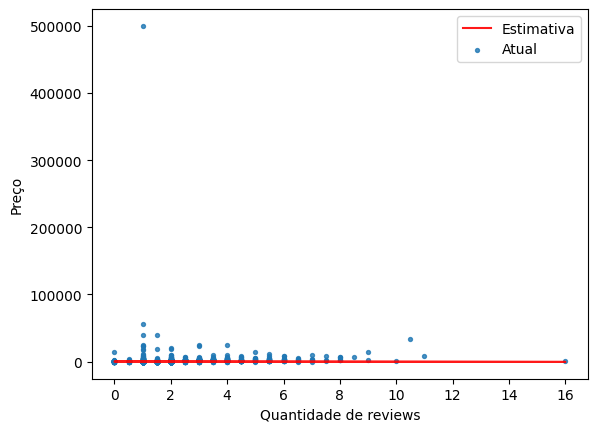

In [308]:
coef_dict = dict(zip(num_cols + cat_cols, pipeline_lasso[-1].coef_))
price_coef = coef_dict['number_of_reviews']
try_parameters(price_coef, pipeline_lasso[-1].intercept_)

## Arvores de regressão

In [309]:
from sklearn.tree import DecisionTreeRegressor

arvore_regressora = DecisionTreeRegressor(max_depth=10, min_samples_leaf=300)

df_arvore_regressora = df_rating_pred.copy()
# df_arvore_regressora = df_arvore_regressora[df_arvore_regressora['review_scores_rating']>=4.2]
# df_arvore_regressora = df_arvore_regressora[df_arvore_regressora['price_cleaned']<=1000]

In [310]:
enc = preprocessing.OneHotEncoder()
enc.fit(df_arvore_regressora[['room_type']])
# enc.categories_
one_hot = enc.transform(df_arvore_regressora[['room_type']]).toarray()
df_arvore_regressora[['Quarto compartilhado', 'Quarto privativo', 'Todo o espaço']] = one_hot

In [311]:
# X = df_arvore_regressora.drop(columns=['review_scores_rating']) 
# y = df_arvore_regressora['review_scores_rating'].values

X = df_arvore_regressora.drop(columns=['price_cleaned'])
y = df_arvore_regressora['price_cleaned'].values

In [312]:

cat_cols = ['host_is_superhost', 'bairro_perigoso', 'instant_bookable', 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado']#, 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado']
# num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'price_cleaned'] #
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']

In [313]:
precomputador = ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')

In [314]:
pipeline_arvore = Pipeline(steps=[
    ('pre-processamento', precomputador),
    ('modelo', arvore_regressora)
])

In [315]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [316]:
pipeline_arvore.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre-processamento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [317]:
print("Score:", pipeline_arvore.score(X_test, y_test))

Score: 0.08019847462081409


In [320]:
mean_squared_error(y_test,y_pred)

1335868.3008058972

In [321]:
df = pd.DataFrame({'Real Values': y_test, 'Predicted_Values': y_pred})


In [322]:
df_resultados_arvore = pd.DataFrame({
    'id_imovel': X_test['id'],       # Busca o ID original que ficou de fora do treino
    'preço_real': y_test,             # A nota real (Target)
    'preço_previsto': y_pred      # A nota que a árvore calculou
})
df_resultados_arvore.reset_index(drop=True, inplace=True)
df_resultados_arvore['erro'] = (df_resultados_arvore['preço_real'] - df_resultados_arvore['preço_previsto']).abs() / df_resultados_arvore['preço_real'] 


fig = px.line(df_resultados_arvore, y=['preço_real', 'preço_previsto'])
fig.show()
print(df_resultados_arvore[df_resultados_arvore['erro'] >=0.1].head())

            id_imovel  preço_real  preço_previsto      erro
0            54387768       216.0      270.459799  0.252129
1  772471073482961996       136.0      172.555126  0.268788
2            41144885       278.0      535.579070  0.926543
3              557344       890.0     2238.966752  1.515693
4            22927640       465.0      172.555126  0.628914


In [323]:
df_treatment[df_treatment['id'] == 1387960272350770082]

,id,name,host_name,host_location,host_response_time,host_is_superhost,neighbourhood,neighbourhood_cleansed,latitude,longitude,...,bedrooms,beds,price,minimum_nights,number_of_reviews,number_of_reviews_l30d,review_scores_rating,instant_bookable,price_cleaned,bairro_perigoso
36875,1387960272350770082,Hidden Garden Ipanema Beach Studio near beach,Scott,"Palm Beach, FL",within an hour,True,"Rio de Janeiro, Brazil",Ipanema,-22.983686,-43.195634,...,0.0,1.0,$424.00,2,10,1,5.0,True,424.0,0


## Ainda a fazer

- precisa de uma limpeza (espaços inteiros -> quarto privado se só tiver um quarto)
- classificar a mudança de preço com base em categorias, acima ou abaixo
- verificar com os valores atuais
- agrupar preços (acredito que diferentes preços indicam pessoas e públicos diferentes, com avaliações diferentes)


In [324]:
limites = [0, 200, 400, 600, 1000, np.inf]
# Exemplo: 0 a 200 (Barato), 200 a 400 (Médio), 400 a 600 (Caro), 600 a 1000 (Muito caro), 1000 a Infinito (Luxo)
nomes_faixas = ['Barato', 'Médio', 'Caro', 'Muito caro', 'Luxo']

df_arvore_regressora['faixa_preco'] = pd.cut(
    df_arvore_regressora['price_cleaned'], 
    bins=limites, 
    labels=nomes_faixas
)

In [325]:
X = df_arvore_regressora[['id', 'faixa_preco'] + cat_cols + num_cols]
y = df_arvore_regressora['review_scores_rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [326]:
from sklearn.base import clone

# Dicionários para guardar os resultados de cada faixa
modelos_por_faixa = {}
resultados_por_faixa = {}

# O groupby vai rodar o código abaixo para cada faixa de preço
for faixa, dados_treino_grupo in X_train.groupby('faixa_preco', observed=False):
    
    # 1. Filtra os y_train correspondentes aos índices deste grupo
    y_treino_grupo = y_train.loc[dados_treino_grupo.index]
    
    # 2. Clona o seu pipeline original para garantir um modelo "zerado" para esta faixa
    pipeline_da_faixa = clone(pipeline_arvore)
    
    # 3. Treina o modelo específico da faixa
    # (O precomputador vai dropar as colunas 'id' e 'faixa_preco' automaticamente!)
    pipeline_da_faixa.fit(dados_treino_grupo, y_treino_grupo)
    
    # 4. Salva o modelo treinado no dicionário
    modelos_por_faixa[faixa] = pipeline_da_faixa
    
    print(f"✅ Modelo treinado com sucesso para a faixa: {faixa}")

✅ Modelo treinado com sucesso para a faixa: Barato
✅ Modelo treinado com sucesso para a faixa: Médio
✅ Modelo treinado com sucesso para a faixa: Caro
✅ Modelo treinado com sucesso para a faixa: Muito caro
✅ Modelo treinado com sucesso para a faixa: Luxo


In [327]:
lista_resultados = []

for faixa, dados_teste_grupo in X_test.groupby('faixa_preco', observed=False):
    y_teste_grupo = y_test.loc[dados_teste_grupo.index]
    
    # Recupera o modelo que foi treinado especificamente para essa faixa
    modelo_da_faixa = modelos_por_faixa[faixa]
    
    # Gera as previsões para este grupo
    previsoes = modelo_da_faixa.predict(dados_teste_grupo)
    
    # Cria o dataframe auxiliar deste grupo com os IDs
    df_res_grupo = pd.DataFrame({
        'id_imovel': dados_teste_grupo['id'],
        'faixa_preco': faixa,
        'nota_real': y_teste_grupo,
        'nota_prevista': previsoes
    })
    
    lista_resultados.append(df_res_grupo)

# Junta todos os resultados de teste em um único DataFrame para consulta
df_resultados_final = pd.concat(lista_resultados, ignore_index=True)
print(df_resultados_final.head())

             id_imovel faixa_preco  nota_real  nota_prevista
0   772471073482961996      Barato       4.88       4.902403
1             16905249      Barato       4.67       4.702276
2   518800174903640943      Barato       4.99       4.975109
3  1457583488164324198      Barato       5.00       5.000000
4             12647682      Barato       4.97       4.975109


In [335]:
# 1. Filtra o DataFrame para conter apenas as linhas da faixa 'Barato'
df_barato = df_resultados_final[df_resultados_final['faixa_preco'] == 'Barato']

# 2. Calcula o R² usando apenas os dados filtrados
r2_barato = r2_score(df_barato['nota_real'], df_barato['nota_prevista'])

# 3. Exibe o resultado
print(f"📊 R² Score para a faixa Barato: {r2_barato:.4f}")

📊 R² Score para a faixa Barato: 0.7221


In [329]:
import plotly.express as px
import plotly.graph_objects as go

# Ordenamos o dataframe para que o gráfico de linha faça sentido visualmente
df_resultados_final = df_resultados_final.sort_values(by='nota_real').reset_index(drop=True)

# Criando o gráfico facetado por faixa de preço
fig = px.line(
    df_resultados_final, 
    y=['nota_real', 'nota_prevista'],
    facet_col='faixa_preco',     # Cria uma coluna de gráfico para cada faixa
    facet_col_wrap=2,            # Quebra a linha a cada 2 gráficos (vira uma grade 2x2)
    title='Comparação: Nota Real vs Nota Prevista por Faixa de Preço',
    labels={'value': 'Nota', 'index': 'Índice do Imóvel'}
)

# Deixa o gráfico mais limpo e bonito
fig.update_layout(hovermode="x unified")
fig.show()

In [330]:
import plotly.express as px

# Gráfico de dispersão: Nota Real vs Nota Prevista
fig = px.scatter(
    df_resultados_final, 
    x='nota_real', 
    y='nota_prevista',
    color='faixa_preco', # Cada faixa de preço ganha uma cor diferente!
    hover_data=['id_imovel'], # Se passar o mouse, você descobre o ID do imóvel
    title='Dispersão de Previsões por Faixa de Preço',
    labels={'nota_real': 'Nota Real', 'nota_prevista': 'Nota Prevista'}
)

# Adiciona uma linha guia diagonal (o cenário perfeito onde Real == Previsto)
fig.add_shape(
    type="line", line=dict(dash='dash', color='black'),
    x0=df_resultados_final['nota_real'].min(), y0=df_resultados_final['nota_real'].min(),
    x1=df_resultados_final['nota_real'].max(), y1=df_resultados_final['nota_real'].max()
)

fig.show()